# CAMA Mean-vs-Sum Aggregation Causal Diagnosis on rel-f1

**Cardinality-Aware Moment Aggregation (CAMA)** controlled experiment on the rel-f1 dataset.

This notebook demonstrates:
1. **CAMA aggregation modules** — PyG `Aggregation` subclasses implementing cardinality-aware gating
2. **Unit tests** — verifying zero-init equivalence and gradient flow
3. **Statistical analysis** — Cohen's d with bootstrap 95% CI, 2-way ANOVA interaction tests
4. **Effective rank measurement** — SVD spectral entropy analysis

**Experiment**: 50 runs (5 methods × 2 tasks × 5 seeds) comparing mean, sum, mean_cama, sum_cama, and mean_ungated aggregations on driver-position (regression) and driver-dnf (classification) tasks.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.15.3',
         'matplotlib==3.10.0', 'statsmodels==0.14.6')

# torch + torch_geometric: pre-installed on Colab; skip locally if not present
# (torch CPU ~200MB download — too slow for quick local demo)
HAS_TORCH = False
try:
    import torch
    HAS_TORCH = True
except ImportError:
    print("torch not available — CAMA module sections will show code only")

HAS_TORCH_GEOMETRIC = False
if HAS_TORCH:
    try:
        from torch_geometric.nn.aggr import Aggregation
        HAS_TORCH_GEOMETRIC = True
    except ImportError:
        try:
            _pip('torch_geometric')
            from torch_geometric.nn.aggr import Aggregation
            HAS_TORCH_GEOMETRIC = True
        except Exception:
            print("torch_geometric not available — CAMA unit tests will be skipped")

print(f"torch: {HAS_TORCH}, torch_geometric: {HAS_TORCH_GEOMETRIC}")


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


torch not available — CAMA module sections will show code only
torch: False, torch_geometric: False


In [2]:
import gc
import json
import math
import os
import warnings

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

if HAS_TORCH:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
if HAS_TORCH_GEOMETRIC:
    from torch_geometric.nn.aggr import Aggregation, MeanAggregation, SumAggregation

warnings.filterwarnings("ignore")

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-9b0386-rank-aware-moment-aggregation-diversity-/main/experiment_iter4_cama_mean_vs_su/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['per_run_results'])} experiment results")
print(f"Methods: {data['experiment_config']['methods']}")
print(f"Tasks: {data['experiment_config']['tasks']}")
print(f"Seeds: {data['experiment_config']['seeds']}")

Loaded 50 experiment results
Methods: ['mean', 'sum', 'mean_cama', 'sum_cama', 'mean_ungated']
Tasks: ['driver-position', 'driver-dnf']
Seeds: [42, 123, 456, 789, 1024]


## Configuration

Tunable parameters for the statistical analysis. `N_BOOTSTRAP` controls precision of Cohen's d confidence intervals.

In [5]:
# ── Tunable parameters ──
N_BOOTSTRAP = 500          # original: 10000 — bootstrap iterations for Cohen's d CI
BOOTSTRAP_SEED = 42        # reproducibility seed
CHANNELS = 128             # embedding dimension for CAMA unit tests

METHODS = ["mean", "sum", "mean_cama", "sum_cama", "mean_ungated"]
TASKS = ["driver-position", "driver-dnf"]
COMPARISONS = [
    ("mean_cama_vs_mean", "mean", "mean_cama"),
    ("sum_cama_vs_sum", "sum", "sum_cama"),
    ("sum_vs_mean", "mean", "sum"),
    ("mean_ungated_vs_mean", "mean", "mean_ungated"),
    ("mean_cama_vs_mean_ungated", "mean_ungated", "mean_cama"),
    ("mean_cama_vs_sum", "sum", "mean_cama"),
]

## CAMA Aggregation Modules

Three aggregation modules implementing Cardinality-Aware Moment Aggregation as PyG `Aggregation` subclasses:

- **CAMAAggregation** (mean-based): `output = mean + sigmoid(w·log(N+1) + b) · W_σ(variance)`
- **SumCAMAAggregation** (sum-based): same gating, but sum as base aggregation
- **UngatedMomentAggregation** (ablation): `output = mean + W_σ(variance)` — no cardinality gating

All modules are **zero-initialized** so they start equivalent to their base aggregation (mean or sum).

In [6]:
if HAS_TORCH_GEOMETRIC:
    class CAMAAggregation(Aggregation):
        """Cardinality-Aware Moment Aggregation (mean-based).
        g = sigmoid(w * log(N+1) + b)
        output = mean + g * W_sigma(variance)
        """
        def __init__(self, channels: int, eps: float = 1e-8):
            super().__init__()
            self.channels = channels
            self.eps = eps
            self.W_sigma = nn.Linear(channels, channels, bias=False)
            self.w_gate = nn.Parameter(torch.zeros(1))
            self.b_gate = nn.Parameter(torch.zeros(1))
            nn.init.zeros_(self.W_sigma.weight)

        def forward(self, x, index=None, ptr=None, dim_size=None, dim=-2,
                    max_num_elements=None):
            mean = self.reduce(x, index, ptr, dim_size, dim, reduce='mean')
            mean_x2 = self.reduce(x * x, index, ptr, dim_size, dim, reduce='mean')
            var = (mean_x2 - mean * mean).clamp(min=0)
            ones = torch.ones(x.size(0), 1, device=x.device, dtype=x.dtype)
            N = self.reduce(ones, index, ptr, dim_size, dim, reduce='sum')
            log_N = torch.log1p(N)
            g = torch.sigmoid(self.w_gate * log_N + self.b_gate)
            return mean + g * self.W_sigma(var)


    class SumCAMAAggregation(Aggregation):
        """CAMA variant with sum as base aggregation."""
        def __init__(self, channels: int, eps: float = 1e-8):
            super().__init__()
            self.channels = channels
            self.eps = eps
            self.W_sigma = nn.Linear(channels, channels, bias=False)
            self.w_gate = nn.Parameter(torch.zeros(1))
            self.b_gate = nn.Parameter(torch.zeros(1))
            nn.init.zeros_(self.W_sigma.weight)

        def forward(self, x, index=None, ptr=None, dim_size=None, dim=-2,
                    max_num_elements=None):
            sum_result = self.reduce(x, index, ptr, dim_size, dim, reduce='sum')
            mean_result = self.reduce(x, index, ptr, dim_size, dim, reduce='mean')
            mean_x2 = self.reduce(x * x, index, ptr, dim_size, dim, reduce='mean')
            var = (mean_x2 - mean_result * mean_result).clamp(min=0)
            ones = torch.ones(x.size(0), 1, device=x.device, dtype=x.dtype)
            N = self.reduce(ones, index, ptr, dim_size, dim, reduce='sum')
            log_N = torch.log1p(N)
            g = torch.sigmoid(self.w_gate * log_N + self.b_gate)
            return sum_result + g * self.W_sigma(var)


    class UngatedMomentAggregation(Aggregation):
        """Mean + W_sigma(variance) without any gating (ablation)."""
        def __init__(self, channels: int):
            super().__init__()
            self.channels = channels
            self.W_sigma = nn.Linear(channels, channels, bias=False)
            nn.init.zeros_(self.W_sigma.weight)

        def forward(self, x, index=None, ptr=None, dim_size=None, dim=-2,
                    max_num_elements=None):
            mean = self.reduce(x, index, ptr, dim_size, dim, reduce='mean')
            mean_x2 = self.reduce(x * x, index, ptr, dim_size, dim, reduce='mean')
            var = (mean_x2 - mean * mean).clamp(min=0)
            return mean + self.W_sigma(var)


    def get_aggr_for_method(method: str, channels: int):
        """Return aggregation object/string for a given method name."""
        if method == "mean":
            return "mean"
        elif method == "sum":
            return "sum"
        elif method == "mean_cama":
            return CAMAAggregation(channels=channels)
        elif method == "sum_cama":
            return SumCAMAAggregation(channels=channels)
        elif method == "mean_ungated":
            return UngatedMomentAggregation(channels=channels)
        else:
            raise ValueError(f"Unknown method: {method}")

    print("CAMA aggregation modules defined successfully.")
else:
    print("Skipping CAMA module definitions (requires torch + torch_geometric).")
    print("On Google Colab, these modules will be fully functional.")

Skipping CAMA module definitions (requires torch + torch_geometric).
On Google Colab, these modules will be fully functional.


## Unit Tests

Verify that zero-initialized CAMA modules produce identical output to their base aggregation (mean/sum), and that gradients flow correctly through the gating mechanism.

In [7]:
if HAS_TORCH_GEOMETRIC:
    print("Running CAMA unit tests...")
    torch.manual_seed(42)
    x = torch.randn(100, CHANNELS)
    index = torch.randint(0, 10, (100,))

    cama = CAMAAggregation(channels=CHANNELS)
    out = cama(x, index=index, dim_size=10)
    assert out.shape == (10, CHANNELS), f"CAMA shape wrong: {out.shape}"
    print("  T1a PASS: CAMAAggregation shape (10, 128)")

    mean_aggr = MeanAggregation()
    out_mean = mean_aggr(x, index=index, dim_size=10)
    assert torch.allclose(out, out_mean, atol=1e-5)
    print("  T1b PASS: Zero-init CAMA matches mean aggregation")

    ungated = UngatedMomentAggregation(channels=CHANNELS)
    out_u = ungated(x, index=index, dim_size=10)
    assert out_u.shape == (10, CHANNELS)
    assert torch.allclose(out_u, out_mean, atol=1e-5)
    print("  T1c PASS: UngatedMomentAggregation shape and zero-init")

    sum_cama = SumCAMAAggregation(channels=CHANNELS)
    out_sc = sum_cama(x, index=index, dim_size=10)
    assert out_sc.shape == (10, CHANNELS)
    sum_aggr = SumAggregation()
    out_sum = sum_aggr(x, index=index, dim_size=10)
    assert torch.allclose(out_sc, out_sum, atol=1e-5)
    print("  T1d PASS: SumCAMAAggregation shape and zero-init matches sum")

    cama2 = CAMAAggregation(channels=CHANNELS)
    x2 = torch.randn(100, CHANNELS, requires_grad=True)
    out2 = cama2(x2, index=index, dim_size=10)
    out2.sum().backward()
    assert cama2.w_gate.grad is not None
    assert cama2.W_sigma.weight.grad is not None
    print("  T1e PASS: Gradient flow through CAMA verified")
    print("All unit tests PASSED!")
else:
    print("Skipping unit tests (requires torch + torch_geometric).")

Skipping unit tests (requires torch + torch_geometric).


## Effective Rank Measurement

Measures representation diversity via SVD spectral entropy: `erank = exp(H)` where `H = -sum(p_i log p_i)` over normalized singular values. Lower effective rank indicates more representation collapse.

In [8]:
if HAS_TORCH:
    def compute_effective_rank(X: torch.Tensor) -> dict:
        if X.shape[0] < 2 or X.shape[1] < 2:
            return {"erank": 1.0, "normalized_erank": 1.0, "num_rows": X.shape[0]}
        try:
            U, S, V = torch.linalg.svd(X.float(), full_matrices=False)
            S = S[S > 1e-10]
            if len(S) == 0:
                return {"erank": 1.0, "normalized_erank": 0.0, "num_rows": X.shape[0]}
            p = S / S.sum()
            H = -(p * p.log()).sum().item()
            erank = math.exp(H)
            max_rank = min(X.shape[0], X.shape[1])
            return {"erank": round(erank, 4), "normalized_erank": round(erank / max_rank, 4),
                    "num_rows": X.shape[0], "num_singular_values": len(S)}
        except Exception as e:
            return {"erank": float("nan"), "normalized_erank": float("nan"), "num_rows": X.shape[0]}

    # Demonstrate on synthetic data
    torch.manual_seed(42)
    X_diverse = torch.randn(200, CHANNELS)
    X_collapsed = torch.randn(200, 1).expand(-1, CHANNELS) + 0.01 * torch.randn(200, CHANNELS)

    rank_diverse = compute_effective_rank(X_diverse)
    rank_collapsed = compute_effective_rank(X_collapsed)
    print(f"Diverse embeddings:   erank = {rank_diverse['erank']:.2f} / {CHANNELS}")
    print(f"Collapsed embeddings: erank = {rank_collapsed['erank']:.2f} / {CHANNELS}")
else:
    print("Skipping live SVD demo (requires torch).")

# Always show pre-computed rank analysis from the experiment
print(f"\nPre-computed rank analysis from experiment:")
rank_data = data['rank_analysis']
print(f"  Mean aggregation erank: {rank_data['mean_aggregation']['entity_embeddings']['erank']:.2f}")
print(f"  Sum aggregation erank:  {rank_data['sum_aggregation']['entity_embeddings']['erank']:.2f}")
print(f"  Collapse ratio (mean/sum): {rank_data['collapse_ratio']:.4f}")

Skipping live SVD demo (requires torch).

Pre-computed rank analysis from experiment:
  Mean aggregation erank: 18.01
  Sum aggregation erank:  22.53
  Collapse ratio (mean/sum): 0.7993


## Statistical Analysis

Cohen's d effect size with bootstrap 95% CI and permutation p-value, plus 2-way ANOVA interaction test for CAMA × aggregation type.

In [9]:
def cohens_d(g1: np.ndarray, g2: np.ndarray) -> float:
    n1, n2 = len(g1), len(g2)
    s1, s2 = g1.std(ddof=1), g2.std(ddof=1)
    pooled = math.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
    return float((g2.mean() - g1.mean()) / pooled) if pooled > 1e-12 else 0.0


def bootstrap_cohens_d(g1: np.ndarray, g2: np.ndarray, n_boot: int = N_BOOTSTRAP,
                       seed: int = BOOTSTRAP_SEED) -> dict:
    rng = np.random.RandomState(seed)
    d_obs = cohens_d(g1, g2)
    n1, n2 = len(g1), len(g2)
    d_boot = np.array([cohens_d(g1[rng.choice(n1, n1, replace=True)],
                                g2[rng.choice(n2, n2, replace=True)]) for _ in range(n_boot)])
    ci_low, ci_high = np.percentile(d_boot, [2.5, 97.5])
    combined = np.concatenate([g1, g2])
    count = sum(1 for _ in range(n_boot)
                if abs(cohens_d(combined[rng.permutation(len(combined))[:n1]],
                                combined[rng.permutation(len(combined))[n1:]])) >= abs(d_obs))
    return {"d": round(d_obs, 4), "ci_low": round(float(ci_low), 4),
            "ci_high": round(float(ci_high), 4), "p_value": round(count / n_boot, 4)}


def run_interaction_test(results: list, task_name: str) -> dict:
    relevant = [r for r in results if r["task"] == task_name and
                r["method"] in ["mean", "sum", "mean_cama", "sum_cama"]
                and r.get("test_metrics")]
    if len(relevant) < 4:
        return {"F_stat": None, "p_value": None, "interpretation": "Insufficient data"}
    metric_key = "average_precision" if task_name == "driver-dnf" else "mae"
    rows = []
    for r in relevant:
        aggr_type = "mean" if r["method"] in ["mean", "mean_cama"] else "sum"
        has_cama = "yes" if "cama" in r["method"] else "no"
        rows.append({"aggr": aggr_type, "cama": has_cama,
                      "metric": r["test_metrics"].get(metric_key, float("nan"))})
    df = pd.DataFrame(rows)
    try:
        import statsmodels.api as sm
        from statsmodels.formula.api import ols
        model = ols('metric ~ C(aggr) * C(cama)', data=df).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        key = 'C(aggr):C(cama)'
        if key in anova_table.index:
            F_stat = float(anova_table.loc[key, 'F'])
            p_val = float(anova_table.loc[key, 'PR(>F)'])
        else:
            F_stat, p_val = float("nan"), float("nan")
        if p_val < 0.05:
            interp = f"Significant interaction (p={p_val:.4f}): CAMA benefit depends on aggregation type"
        elif p_val < 0.15:
            interp = f"Trending interaction (p={p_val:.4f}): suggestive but not significant"
        else:
            interp = f"No significant interaction (p={p_val:.4f}): CAMA benefit NOT aggregation-specific"
        return {"F_stat": round(F_stat, 4), "p_value": round(p_val, 4), "interpretation": interp}
    except Exception as e:
        return {"F_stat": None, "p_value": None, "interpretation": f"Failed: {str(e)[:200]}"}

print("Statistical analysis functions defined.")

Statistical analysis functions defined.


## Run Statistical Analysis on Pre-computed Results

Re-compute summary statistics, Cohen's d effect sizes, and interaction tests from the 50 experiment runs.

In [10]:
all_results = data['per_run_results']
valid = [r for r in all_results if r.get("test_metrics")]
print(f"Analyzing {len(valid)} valid experiment results...\n")

# ── Summary table ──
summary_table = {}
for task_name in TASKS:
    is_cls = task_name == "driver-dnf"
    mk = "average_precision" if is_cls else "mae"
    prefix = "test_ap" if is_cls else "test_mae"

    summary_table[task_name] = {}
    for method in METHODS:
        vals = [r["test_metrics"].get(mk) for r in valid
                if r["task"] == task_name and r["method"] == method]
        vals = [v for v in vals if v is not None and not math.isnan(v)]
        if not vals:
            continue
        arr = np.array(vals)
        summary_table[task_name][method] = {
            f"{prefix}_mean": round(float(arr.mean()), 4),
            f"{prefix}_std": round(float(arr.std(ddof=1)) if len(arr) > 1 else 0.0, 4),
            "n_seeds": len(vals),
        }

# ── Cohen's d comparisons ──
cohens_d_comparisons = {}
for task_name in TASKS:
    is_cls = task_name == "driver-dnf"
    mk = "average_precision" if is_cls else "mae"
    higher = is_cls
    cohens_d_comparisons[task_name] = {}
    for comp_name, base_m, test_m in COMPARISONS:
        bvals = [r["test_metrics"].get(mk) for r in valid
                 if r["task"] == task_name and r["method"] == base_m]
        tvals = [r["test_metrics"].get(mk) for r in valid
                 if r["task"] == task_name and r["method"] == test_m]
        bvals = [v for v in bvals if v is not None and not math.isnan(v)]
        tvals = [v for v in tvals if v is not None and not math.isnan(v)]
        if len(bvals) < 2 or len(tvals) < 2:
            cohens_d_comparisons[task_name][comp_name] = {"d": None}
            continue
        g1, g2 = np.array(bvals), np.array(tvals)
        if not higher:  # MAE: lower is better, flip for positive d = improvement
            result = bootstrap_cohens_d(g2, g1)
        else:
            result = bootstrap_cohens_d(g1, g2)
        cohens_d_comparisons[task_name][comp_name] = result

# ── Interaction tests ──
interaction_tests = {}
for task_name in TASKS:
    interaction_tests[task_name] = run_interaction_test(valid, task_name)

# ── Print summary ──
for task_name in TASKS:
    print(f"{'='*60}")
    print(f"Task: {task_name}")
    print(f"{'='*60}")
    st = summary_table[task_name]
    for method, vals in st.items():
        mk = [k for k in vals if k.endswith("_mean")]
        if mk:
            print(f"  {method:20s}: {mk[0]}={vals[mk[0]]:.4f} +/- {vals[mk[0].replace('_mean','_std')]:.4f}")

    print(f"\n  Cohen's d comparisons:")
    for comp_name, cd in cohens_d_comparisons[task_name].items():
        if cd.get("d") is not None:
            print(f"    {comp_name:30s}: d={cd['d']:+.3f}  CI=[{cd['ci_low']:.3f}, {cd['ci_high']:.3f}]  p={cd['p_value']:.4f}")

    it = interaction_tests[task_name]
    print(f"\n  Interaction test: {it['interpretation']}")
    print()

Analyzing 50 valid experiment results...



Task: driver-position
  mean                : test_mae_mean=3.2114 +/- 0.0371
  sum                 : test_mae_mean=3.2209 +/- 0.0534
  mean_cama           : test_mae_mean=3.2242 +/- 0.0617
  sum_cama            : test_mae_mean=3.2182 +/- 0.0169
  mean_ungated        : test_mae_mean=3.2345 +/- 0.0645

  Cohen's d comparisons:
    mean_cama_vs_mean             : d=-0.252  CI=[-2.399, 0.872]  p=0.5980
    sum_cama_vs_sum               : d=+0.067  CI=[-2.092, 1.385]  p=0.8760
    sum_vs_mean                   : d=-0.206  CI=[-1.431, 1.296]  p=0.6580
    mean_ungated_vs_mean          : d=-0.439  CI=[-1.417, 1.414]  p=0.3760
    mean_cama_vs_mean_ungated     : d=+0.163  CI=[-2.953, 1.314]  p=0.7000
    mean_cama_vs_sum              : d=-0.058  CI=[-2.027, 1.119]  p=0.8900

  Interaction test: No significant interaction (p=0.7094): CAMA benefit NOT aggregation-specific

Task: driver-dnf
  mean                : test_ap_mean=0.9019 +/- 0.0008
  sum                 : test_ap_mean=0.8972 +/- 0.0

## Results Visualization

Four-panel figure showing: (1) test metrics by method/task, (2) Cohen's d forest plot, (3) effective rank comparison, and (4) training loss curves.

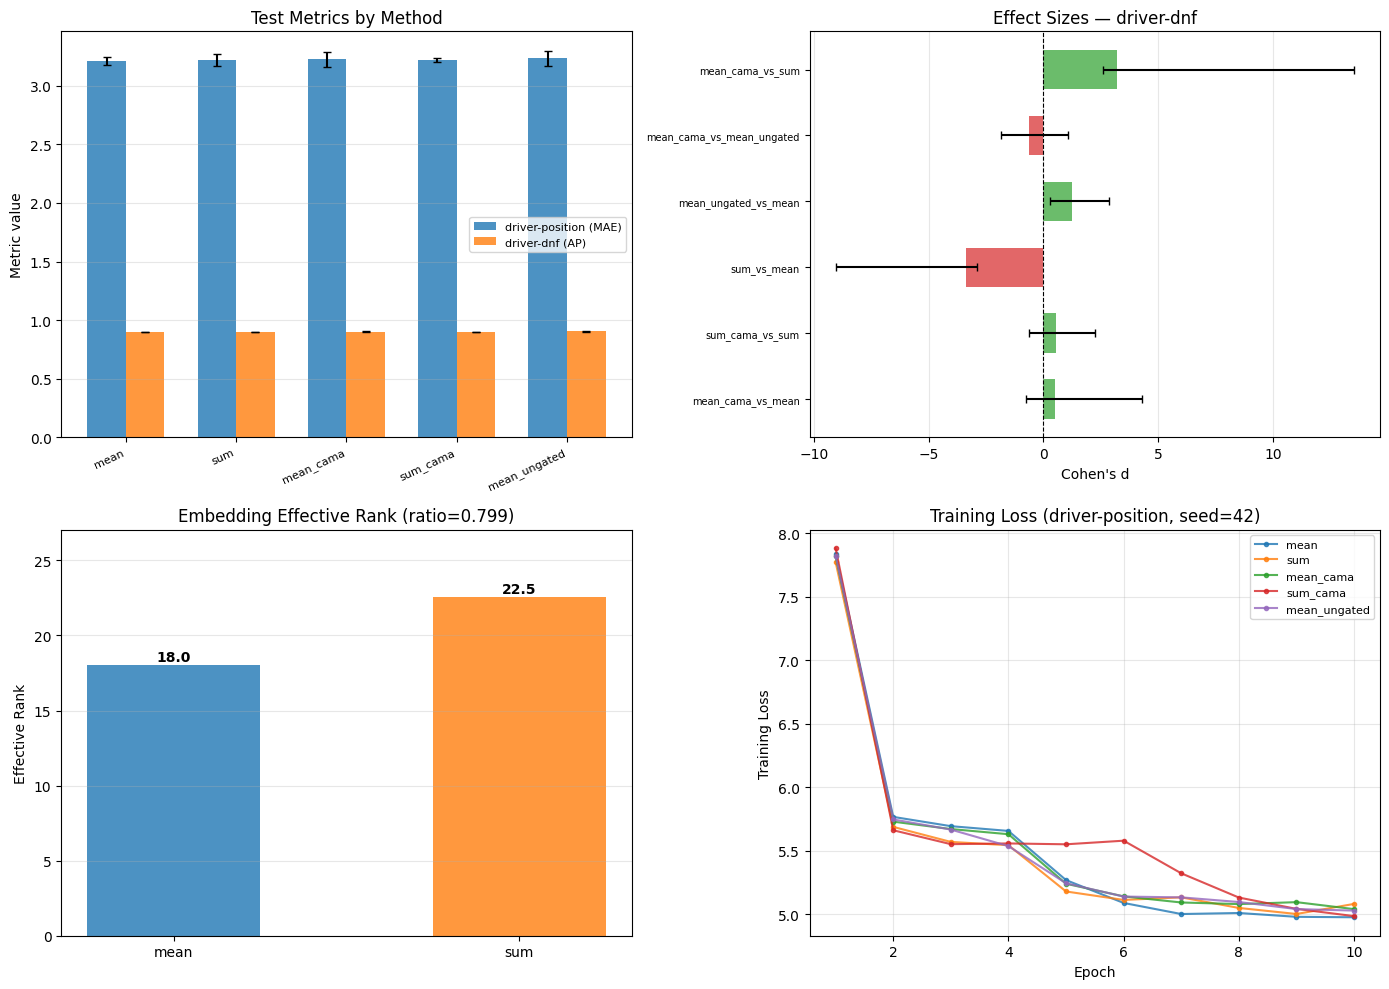

Visualization saved to results_visualization.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Panel 1: Test metrics by method (grouped bar chart) ──
ax = axes[0, 0]
x_pos = np.arange(len(METHODS))
width = 0.35
for i, task_name in enumerate(TASKS):
    is_cls = task_name == "driver-dnf"
    mk = "average_precision" if is_cls else "mae"
    means = []
    stds = []
    for method in METHODS:
        vals = [r["test_metrics"].get(mk) for r in valid
                if r["task"] == task_name and r["method"] == method]
        vals = [v for v in vals if v is not None]
        means.append(np.mean(vals) if vals else 0)
        stds.append(np.std(vals, ddof=1) if len(vals) > 1 else 0)
    offset = (i - 0.5) * width
    label = f"{task_name} ({'AP' if is_cls else 'MAE'})"
    ax.bar(x_pos + offset, means, width, yerr=stds, label=label, alpha=0.8, capsize=3)
ax.set_xticks(x_pos)
ax.set_xticklabels(METHODS, rotation=25, ha='right', fontsize=8)
ax.set_ylabel("Metric value")
ax.set_title("Test Metrics by Method")
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ── Panel 2: Cohen's d forest plot (driver-dnf) ──
ax = axes[0, 1]
task_plot = "driver-dnf"
comps = cohens_d_comparisons.get(task_plot, {})
comp_names = [cn for cn in comps if comps[cn].get("d") is not None]
y_pos = np.arange(len(comp_names))
ds = [comps[cn]["d"] for cn in comp_names]
ci_lows = [comps[cn]["ci_low"] for cn in comp_names]
ci_highs = [comps[cn]["ci_high"] for cn in comp_names]
xerr_low = [d - cl for d, cl in zip(ds, ci_lows)]
xerr_high = [ch - d for d, ch in zip(ds, ci_highs)]
colors = ['tab:green' if d > 0 else 'tab:red' for d in ds]
ax.barh(y_pos, ds, xerr=[xerr_low, xerr_high], color=colors, alpha=0.7, capsize=3, height=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(comp_names, fontsize=7)
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel("Cohen's d")
ax.set_title(f"Effect Sizes — {task_plot}")
ax.grid(axis='x', alpha=0.3)

# ── Panel 3: Effective rank comparison ──
ax = axes[1, 0]
rank_data = data['rank_analysis']
methods_rank = ['mean', 'sum']
eranks = [rank_data[f'{m}_aggregation']['entity_embeddings']['erank'] for m in methods_rank]
bars = ax.bar(methods_rank, eranks, color=['tab:blue', 'tab:orange'], alpha=0.8, width=0.5)
for bar, er in zip(bars, eranks):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{er:.1f}',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel("Effective Rank")
ax.set_title(f"Embedding Effective Rank (ratio={rank_data['collapse_ratio']:.3f})")
ax.set_ylim(0, max(eranks) * 1.2)
ax.grid(axis='y', alpha=0.3)

# ── Panel 4: Training loss curves (one seed per method, driver-position) ──
ax = axes[1, 1]
for method in METHODS:
    runs = [r for r in valid if r["task"] == "driver-position" and r["method"] == method
            and r.get("train_losses")]
    if runs:
        losses = runs[0]["train_losses"]
        ax.plot(range(1, len(losses)+1), losses, marker='o', markersize=3, label=method, alpha=0.8)
ax.set_xlabel("Epoch")
ax.set_ylabel("Training Loss")
ax.set_title("Training Loss (driver-position, seed=42)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("results_visualization.png", dpi=100, bbox_inches='tight')
plt.show()
print("Visualization saved to results_visualization.png")